In [ ]:
!pip -q install umap-learn==0.5.6 scikit-learn==1.5.1 scipy pandas pyarrow
!pip install umap-learn[plot]
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 66.1 MB/s eta 0:00:00


In [ ]:
# Core
import numpy as np
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.4)
import plotly.express as px
import requests

# Sklearn
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# UMAP
import umap
import umap.plot

from scipy.stats import ttest_ind


/usr/local/lib/python3.12/dist-packages/cudf/utils/gpu_utils.py:75: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))
/usr/local/lib/python3.12/dist-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/usr/local/lib/python3.12/dist-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/usr/local/lib/python3.12/dist-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calli

1. Скачайте данные экспрессии (bulk RNA-seq) плоскоклеточного рака головы и шеи проекта TCGA.
[Ссылка на транскрипты](https://xenabrowser.net/datapages/?dataset=TCGA-HNSC.star_fpkm-uq.tsv&host=https%3A%2F%2Fgdc.xenahubs.net&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443)


In [ ]:
!wget -O TCGA-HNSC.star_fpkm-uq.tsv.gz "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-HNSC.star_fpkm-uq.tsv.gz"
!gunzip -f TCGA-HNSC.star_fpkm-uq.tsv.gz

--2025-08-25 07:00:07--  https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-HNSC.star_fpkm-uq.tsv.gz
Resolving gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)... 3.5.8.199, 52.216.244.8, 16.15.218.151, ...
Connecting to gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)|3.5.8.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 142260818 (136M) [text/tab-separated-values]
Saving to: ‘TCGA-HNSC.star_fpkm-uq.tsv.gz’

TCGA-HNSC.star_fpkm 100%[===================>] 135.67M  56.8MB/s    in 2.4s    

2025-08-25 07:00:10 (56.8 MB/s) - ‘TCGA-HNSC.star_fpkm-uq.tsv.gz’ saved [142260818/142260818]



Открыла файл в pandas, посмотрела его размер (сколько генов × сколько образцов) и вывела первые строки, чтобы убедиться, что всё в порядке.

In [ ]:
expr = pd.read_csv("TCGA-HNSC.star_fpkm-uq.tsv", sep="\t", index_col=0) #первая колонка (с названиями генов) будет использоваться как индекс строк.

print("Размер матрицы:", expr.shape) #вывожу размер страницы
expr.head()

Размер матрицы: (60660, 566)


,TCGA-CR-7370-01A,TCGA-CR-6484-01A,TCGA-CR-6478-01A,TCGA-CV-A45Y-01A,TCGA-UF-A719-01A,TCGA-CR-6488-01A,TCGA-MZ-A7D7-01A,TCGA-CV-5436-01A,TCGA-UF-A71E-01A,TCGA-P3-A6T3-01A,...,TCGA-HD-7753-01A,TCGA-CV-A6JE-01A,TCGA-CV-A45Z-01A,TCGA-CV-6939-11A,TCGA-CV-7432-11A,TCGA-CV-7432-01A,TCGA-IQ-7630-01A,TCGA-H7-A6C4-11A,TCGA-H7-8501-01A,TCGA-CV-7415-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,3.940073,2.627677,2.484602,3.277702,4.350335,3.044709,4.352787,1.877352,3.422368,4.025862,...,3.041278,4.051407,3.595432,3.829768,4.964528,3.274754,3.035061,3.300666,3.010064,3.068997
ENSG00000000005.6,0.000000,0.000000,0.014498,0.000000,0.000000,0.016211,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.213316,0.041103,0.000000,0.000000,1.638584,0.030972,0.017637
ENSG00000000419.13,4.158095,5.235019,4.754834,4.757855,4.674082,5.043694,6.692218,5.807347,4.734910,5.802271,...,5.309504,5.006567,5.741397,4.549706,4.400217,5.094988,5.669622,5.305661,6.160567,4.893081
ENSG00000000457.14,1.760562,1.498098,1.402831,1.405775,1.906236,1.281728,1.658783,1.087463,1.693320,0.968201,...,1.220206,0.839798,1.322620,1.679154,2.075225,1.042364,1.076217,1.343976,1.463779,0.943359
ENSG00000000460.17,2.135108,1.673873,2.002739,1.050885,2.130700,1.105879,1.797594,1.359352,1.664619,1.239765,...,1.300944,0.602932,1.243974,0.337197,0.691713,2.008343,1.324465,0.420725,1.946843,0.844627


Выбираю 2000 наиболее вариабельных генов (HVG — highly variable genes). Выбрала такой метод, тк он показался мне самым подходящим для кластеризации. T - транпонирование, строки = образцы, столбцы = гены

expr.shap - чтобы проверить отбор

In [ ]:
N_HVG = 2000 # тк не работала раньше с сиквенсали илюмины, взяла 2000 из протокола, как поняла это стандарно чтобы сбалансировать данные
gene_var = expr.var(axis=1) #считаю дисперсию, чтобы понять насколько меняется активность каждого гена между образцами
top_genes = gene_var.sort_values(ascending=False).head(N_HVG).index # сортирую и беру 2к самых вариабельных

expr_hvg = expr.loc[top_genes].T  # Транспонирую таблицу, образцы × гены
print("Форма матрицы для анализа:", expr_hvg.shape)

Форма матрицы для анализа: (566, 2000)


# PCA
Постройте PCA и UMAP плоты ет на этих данных. Выбор наилучшего набора генов для этих репрезентаций осуществляется на ваше усмотрение.

снижаем размерность до 2х компанент

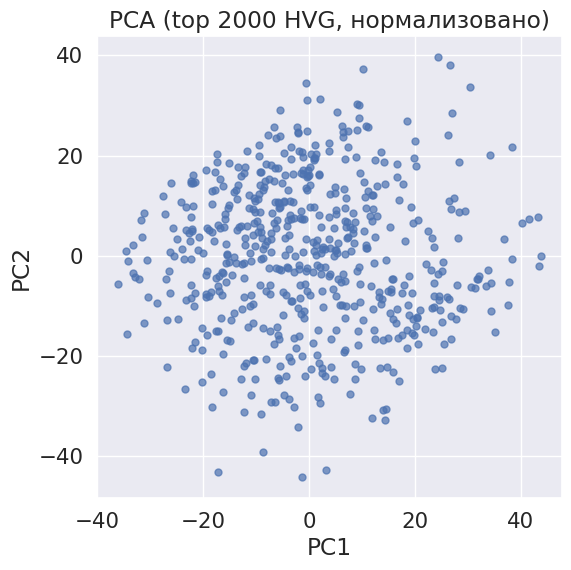

In [ ]:
expr_hvg_log = np.log2(expr_hvg + 1) #версия с нормализацией

scaler = StandardScaler()
expr_hvg_scaled = scaler.fit_transform(expr_hvg_log)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(expr_hvg_scaled)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7, s=25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (top 2000 HVG, нормализовано)")
plt.show()

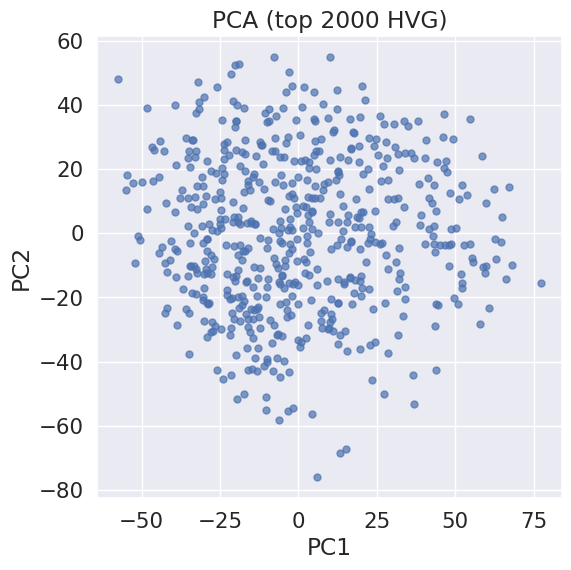

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(expr_hvg)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7, s=25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (top 2000 HVG)")
plt.show()

# UMAP


У алгоритма UMAP тоже есть два ключевых гиперпараметра, которые могут очень сильно влиять на результат:

min_dist - насколько близко соседние точки могут находиться в эмбеддинге
n_neighbors - упрощенно: примерное количество точек в окрестности, которые учитываются алгоритмом

n_neighbors рекомендуют выбирать... тоже в диапазоне 5 - 50! Правда, это уже целое число.

min_dist обычно берут в диапазоне от 0.001 до 0.5.

Чем больше значение (min_dist), тем больше смещается акцент с локальной структуры на глобальную.
Это помогает соблюсти баланс для отображения максимально полной структуры на одном графике.
n_neighbors - параметр, определяющий количество соседей у узлов в графе.
Так же, как и min_dist, помогает поддерживать баланс акцента на локальной/глобальной структуре.
Более высокие значения смещают общее отображение к глобальной топологии данных.
Недостаточно выскоие значения могут породить "кластеры".

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


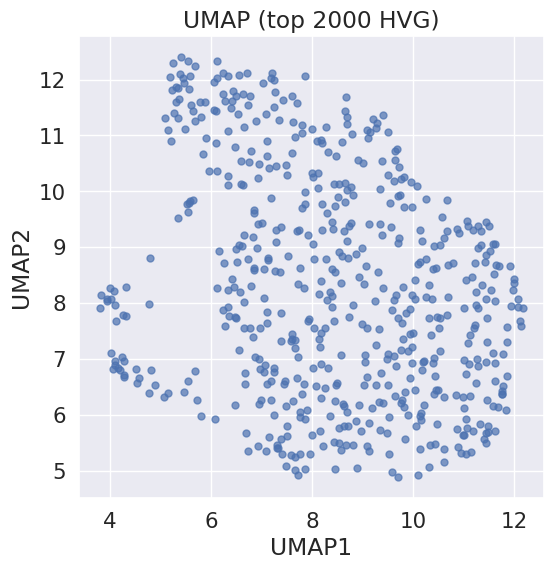

In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric="cosine", random_state=42)
X_umap = reducer.fit_transform(expr_hvg)

plt.figure(figsize=(6,6))
plt.scatter(X_umap[:,0], X_umap[:,1], alpha=0.7, s=25)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP (top 2000 HVG)")
plt.show()

# Иерархическая кластеризация

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


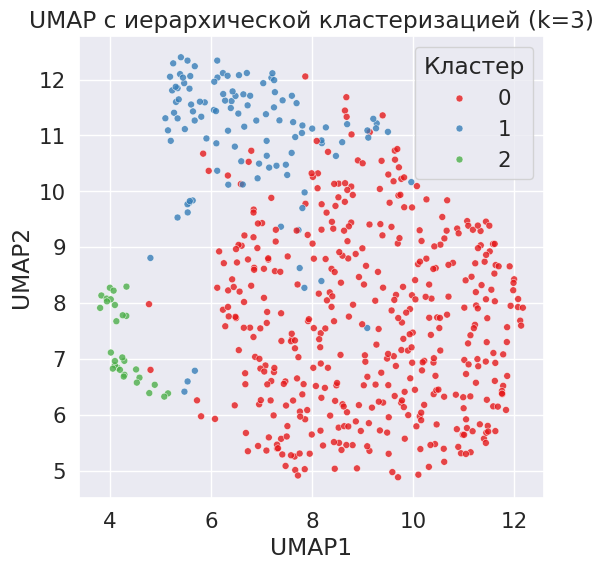

In [ ]:


reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric="cosine", random_state=42)
X_umap = reducer.fit_transform(expr_hvg)

n_clusters = 3
clust = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
labels = clust.fit_predict(expr_hvg)

plt.figure(figsize=(6,6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=labels,
                palette="Set1", s=25, alpha=0.8)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title(f"UMAP с иерархической кластеризацией (k={n_clusters})")
plt.legend(title="Кластер")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,2,0.102956,48.541598,2.632823
1,3,0.105131,40.733278,2.305878
2,4,0.063121,39.031158,2.808009
3,5,0.069978,38.769534,2.613006
4,6,0.054270,35.580885,2.623053
5,7,0.046235,32.992053,2.820786
6,8,0.052272,31.005501,2.679929
7,9,0.057841,29.508475,2.579490
8,10,0.056192,28.125895,2.566988


 k = 3


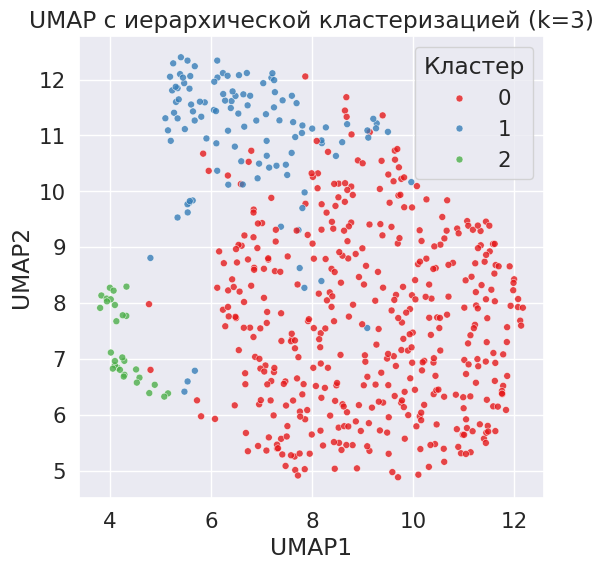

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import umap

#UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, metric="cosine", random_state=42)
X_umap = reducer.fit_transform(expr_hvg)

scores = []
range_n = range(2, 11)

for k in range_n:
    clust = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = clust.fit_predict(expr_hvg)

    sil = silhouette_score(expr_hvg, labels)
    ch = calinski_harabasz_score(expr_hvg, labels)
    db = davies_bouldin_score(expr_hvg, labels)

    scores.append((k, sil, ch, db))

scores_df = pd.DataFrame(scores, columns=["n_clusters", "silhouette", "calinski_harabasz", "davies_bouldin"])
display(scores_df)

# Тут я хочу понять сколько кластеров мне нужно
# Максимальный silhouette или Calinski-Harabasz, минимальный Davies-Bouldin
best_k = scores_df.loc[scores_df["silhouette"].idxmax(), "n_clusters"]
print(f" k = {best_k}")

clust = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels = clust.fit_predict(expr_hvg)

plt.figure(figsize=(6,6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=labels,
                palette="Set1", s=25, alpha=0.8)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title(f"UMAP с иерархической кластеризацией (k={best_k})")
plt.legend(title="Кластер")
plt.show()

In [ ]:
!wget -O TCGA-HNSC.star_counts.tsv.gz "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-HNSC.star_counts.tsv.gz"
!gunzip -f TCGA-HNSC.star_counts.tsv.gz

--2025-08-25 07:00:48--  https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-HNSC.star_counts.tsv.gz
Resolving gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)... 16.182.68.242, 16.182.68.170, 52.217.198.210, ...
Connecting to gdc-hub.s3.us-east-1.amazonaws.com (gdc-hub.s3.us-east-1.amazonaws.com)|16.182.68.242|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61155089 (58M) [text/tab-separated-values]
Saving to: ‘TCGA-HNSC.star_counts.tsv.gz’

TCGA-HNSC.star_coun 100%[===================>]  58.32M  57.1MB/s    in 1.0s    

2025-08-25 07:00:49 (57.1 MB/s) - ‘TCGA-HNSC.star_counts.tsv.gz’ saved [61155089/61155089]



In [ ]:
counts = pd.read_csv("TCGA-HNSC.star_counts.tsv", sep="\t", index_col=0)
print( counts.shape)
counts.head()

(60660, 566)


,TCGA-CR-7370-01A,TCGA-CR-6484-01A,TCGA-CR-6478-01A,TCGA-CV-A45Y-01A,TCGA-UF-A719-01A,TCGA-CR-6488-01A,TCGA-MZ-A7D7-01A,TCGA-CV-5436-01A,TCGA-UF-A71E-01A,TCGA-P3-A6T3-01A,...,TCGA-HD-7753-01A,TCGA-CV-A6JE-01A,TCGA-CV-A45Z-01A,TCGA-CV-6939-11A,TCGA-CV-7432-11A,TCGA-CV-7432-01A,TCGA-IQ-7630-01A,TCGA-H7-A6C4-11A,TCGA-H7-8501-01A,TCGA-CV-7415-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,12.131535,10.087463,10.456354,10.501837,12.338179,10.944712,11.386940,8.921841,10.929998,11.243174,...,10.953469,11.067434,11.032046,10.646559,12.648582,10.983706,10.952741,9.837628,9.962896,10.847840
ENSG00000000005.6,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.727920,1.584963,0.000000,0.000000,6.169925,1.000000,1.000000
ENSG00000000419.13,10.454299,11.000000,11.045760,10.174926,10.767357,11.175550,11.874597,11.371777,10.418907,11.174926,...,11.461479,10.157347,11.365229,9.499846,10.152285,11.008429,11.836050,10.049849,11.373409,10.895575
ENSG00000000457.14,10.147205,9.184875,9.575539,8.707359,10.121534,9.207014,8.820179,8.276124,9.411511,7.851749,...,9.113742,7.375039,8.751544,8.665336,10.018200,8.554589,8.857981,7.918863,8.562242,8.451211
ENSG00000000460.17,10.448116,9.243174,10.240791,7.882643,10.214319,8.689998,8.813781,8.546894,9.164907,8.154818,...,9.047124,6.569856,8.413628,5.426265,7.434628,9.859535,9.092757,5.554589,9.055282,8.033423


In [ ]:
# Убираю версии у ENSG
counts.index = counts.index.str.replace(r"\.\d+$", "", regex=True)
print()
# Загружаю probemap
probemap_url = "https://gdc-hub.s3.us-east-1.amazonaws.com/download/gencode.v36.annotation.gtf.gene.probemap"
probemap = pd.read_csv(probemap_url, sep="\t")

id2gene = dict(zip(probemap["id"], probemap["gene"]))
counts = counts.rename(index=id2gene)

print(counts.shape)
counts.head()


(60660, 566)


,TCGA-CR-7370-01A,TCGA-CR-6484-01A,TCGA-CR-6478-01A,TCGA-CV-A45Y-01A,TCGA-UF-A719-01A,TCGA-CR-6488-01A,TCGA-MZ-A7D7-01A,TCGA-CV-5436-01A,TCGA-UF-A71E-01A,TCGA-P3-A6T3-01A,...,TCGA-HD-7753-01A,TCGA-CV-A6JE-01A,TCGA-CV-A45Z-01A,TCGA-CV-6939-11A,TCGA-CV-7432-11A,TCGA-CV-7432-01A,TCGA-IQ-7630-01A,TCGA-H7-A6C4-11A,TCGA-H7-8501-01A,TCGA-CV-7415-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,12.131535,10.087463,10.456354,10.501837,12.338179,10.944712,11.386940,8.921841,10.929998,11.243174,...,10.953469,11.067434,11.032046,10.646559,12.648582,10.983706,10.952741,9.837628,9.962896,10.847840
ENSG00000000005,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.727920,1.584963,0.000000,0.000000,6.169925,1.000000,1.000000
ENSG00000000419,10.454299,11.000000,11.045760,10.174926,10.767357,11.175550,11.874597,11.371777,10.418907,11.174926,...,11.461479,10.157347,11.365229,9.499846,10.152285,11.008429,11.836050,10.049849,11.373409,10.895575
ENSG00000000457,10.147205,9.184875,9.575539,8.707359,10.121534,9.207014,8.820179,8.276124,9.411511,7.851749,...,9.113742,7.375039,8.751544,8.665336,10.018200,8.554589,8.857981,7.918863,8.562242,8.451211
ENSG00000000460,10.448116,9.243174,10.240791,7.882643,10.214319,8.689998,8.813781,8.546894,9.164907,8.154818,...,9.047124,6.569856,8.413628,5.426265,7.434628,9.859535,9.092757,5.554589,9.055282,8.033423


In [ ]:
common_samples = counts.columns.intersection(expr_hvg.index)

counts = counts[common_samples]
expr_hvg = expr_hvg.loc[common_samples]

print("Совпадающие образцы:", counts.shape[1])


Совпадающие образцы: 566


In [ ]:
cluster0_samples = expr_hvg.index[labels == 0]
cluster1_samples = expr_hvg.index[labels == 1]

counts_sub = counts[cluster0_samples.tolist() + cluster1_samples.tolist()]

results = []
for gene in counts_sub.index:
    vals0 = counts_sub.loc[gene, cluster0_samples]
    vals1 = counts_sub.loc[gene, cluster1_samples]
    stat, pval = ttest_ind(vals0, vals1, equal_var=False)

    # log2 fold-change
    mean0 = np.mean(vals0 + 1)
    mean1 = np.mean(vals1 + 1)
    log2fc = np.log2(mean1 / mean0)

    results.append((gene, log2fc, pval))

deg_df = pd.DataFrame(results, columns=["gene", "log2FC", "pval"])
deg_df["pval_adj"] = deg_df["pval"] * len(deg_df)
deg_df = deg_df.sort_values("pval_adj").reset_index(drop=True)
deg_df.head(10)

,gene,log2FC,pval,pval_adj
0,ENSG00000248370,-1.536348,1.686005e-57,1.022731e-52
1,ENSG00000183844,0.836123,2.414699e-53,1.464757e-48
2,ENSG00000165238,0.510308,2.908854e-50,1.764511e-45
3,ENSG00000114790,0.423969,1.607704e-49,9.752331e-45
4,ENSG00000184012,0.622239,4.312922e-47,2.616219e-42
5,ENSG00000171345,0.435836,1.270380e-46,7.706127e-42
6,ENSG00000129514,0.534111,1.605118e-46,9.736648e-42
7,ENSG00000139865,0.996346,1.993919e-45,1.209511e-40
8,ENSG00000108924,0.450652,2.238805e-44,1.358059e-39
9,ENSG00000211677,0.352509,1.378926e-43,8.364564e-39
